# Scoring engine — how FPL points are earned, by position
_How the scoring formula turns events into points across positions: the component mix, how often each component fires, how big it is when it does, and a formula-integrity check. DGW excluded — these are per-single-fixture rates._

**Sections:** (a) component mix · (b) event rates · (c) magnitude when it fires · (d) formula reconstruction

---

## Setup
> Whole season, `minutes > 0`, **DGW excluded** (`is_dgw == False`) so every row is a single fixture; build the per-component point contributions from `domain/fpl_scoring.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError
from domain.fpl_scoring import decompose_total_points

POSITIONS = ["GK", "DEF", "MID", "FWD"]
pd.set_option("display.width", 160)

try:
    _r = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _r = load_mart()

mart = _r.mart
df = mart[mart["gw"].between(1, _r.data_cutoff_gw)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()
pos = df["position"]

COMP_ORDER = ["appearance", "goals", "assists", "clean_sheets", "saves", "penalties_saved",
              "bonus", "defensive_contribution", "goals_conceded", "cards", "own_goals", "penalties_missed"]
_event_cols = ["goals_scored", "assists", "clean_sheets", "goals_conceded", "saves",
               "penalties_saved", "bonus", "yellow_cards", "red_cards", "own_goals",
               "penalties_missed", "defensive_contribution"]
# Per-component point contributions via the domain formula (single source of truth).
components = pd.DataFrame(
    [decompose_total_points(position=p, minutes=int(m), **{c: int(v) for c, v in row.items()})
     for p, m, row in zip(df["position"], df["minutes"], df[_event_cols].to_dict("records"))],
    index=df.index,
)[COMP_ORDER]
reconstructed = components.sum(axis=1)

print(f"Study range: GW 1 - {_r.data_cutoff_gw} · minutes > 0 · DGW excluded · n = {len(df):,}")
for p in POSITIONS:
    print(f"  {p}: {(pos == p).sum():>6,}")


def _heatmap(ax, M, rows, cols, cmap, title, fmt="{:.0f}", vmin=None, vmax=None):
    data = np.array(M, dtype=float)
    cm = plt.get_cmap(cmap).copy()
    cm.set_bad("#eeeeee")
    im = ax.imshow(np.ma.masked_invalid(data), cmap=cm, aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(cols))); ax.set_xticklabels(cols)
    ax.set_yticks(range(len(rows))); ax.set_yticklabels(rows)
    hi = vmax if vmax is not None else np.nanmax(np.abs(data))
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            v = data[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=7,
                        color="white" if (hi and abs(v) > 0.6 * hi) else "black")
    ax.set_title(title, fontsize=10)
    return im

Study range: GW 1 - 38 · minutes > 0 · DGW excluded · n = 11,190
  GK:    747
  DEF:  3,845
  MID:  5,208
  FWD:  1,390


## (a) Component mix
> How is each position's scoring built up from the formula's components?

Mean points contributed by each scoring component, per position (negative components stack below zero). This is a pure decomposition of `total_points` into its formula inputs — not an association.

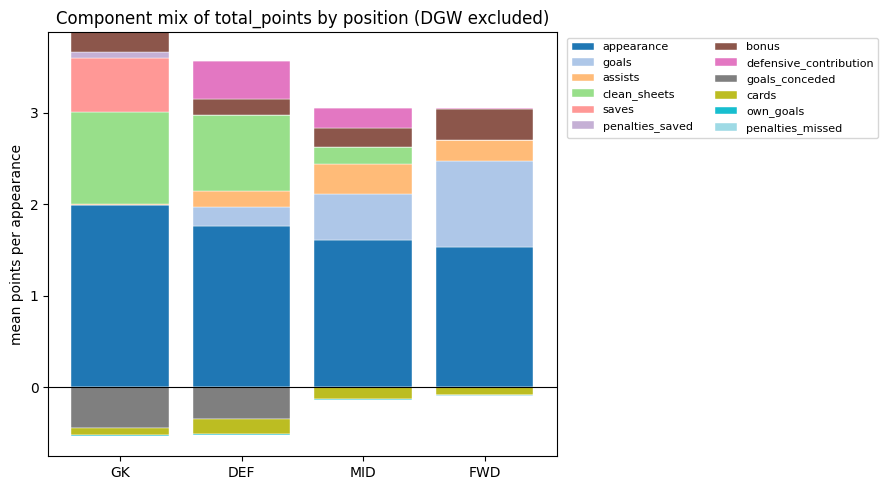

In [2]:
means = components.groupby(pos).mean().reindex(POSITIONS)[COMP_ORDER]
colors = plt.get_cmap("tab20")(np.linspace(0, 1, len(COMP_ORDER)))

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(POSITIONS))
bot_pos = np.zeros(len(POSITIONS))
bot_neg = np.zeros(len(POSITIONS))
for k, c in enumerate(COMP_ORDER):
    vals = means[c].to_numpy()
    bottoms = np.where(vals >= 0, bot_pos, bot_neg)
    ax.bar(x, vals, bottom=bottoms, color=colors[k], label=c, edgecolor="white", linewidth=0.3)
    bot_pos = bot_pos + np.where(vals >= 0, vals, 0.0)
    bot_neg = bot_neg + np.where(vals < 0, vals, 0.0)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels(POSITIONS)
ax.set_ylabel("mean points per appearance")
ax.set_title("Component mix of total_points by position (DGW excluded)")
ax.legend(ncol=2, fontsize=8, bbox_to_anchor=(1.01, 1.0), loc="upper left")
plt.tight_layout()
plt.show()

## (b) Event rates
> How often does each scoring component actually fire?

Share of appearances where each component contributes non-zero points, by position (appearance excluded — it always fires). A clean sheet scores a forward 0 points, so it never "fires" for FWD.

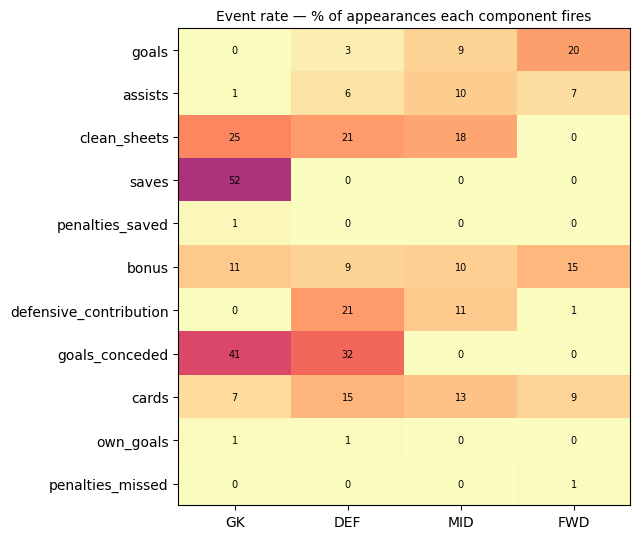

In [3]:
events = [c for c in COMP_ORDER if c != "appearance"]
rate = pd.DataFrame({
    p: [(components.loc[pos == p, c] != 0).mean() * 100 for c in events] for p in POSITIONS
}, index=events)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
_heatmap(ax, rate.values, events, POSITIONS, "magma_r",
         "Event rate — % of appearances each component fires", fmt="{:.0f}", vmin=0, vmax=100)
plt.tight_layout()
plt.show()

## (c) Magnitude when it fires
> When a component fires, how many points does it deliver?

Mean signed point contribution conditional on the component being non-zero, by position. Separates frequent-but-small (a yellow card) from rare-but-large (a goalkeeper goal, a penalty save).

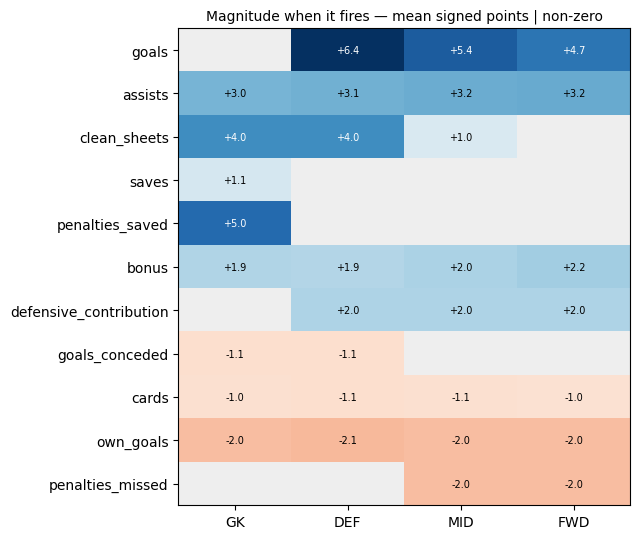

In [4]:
mag = pd.DataFrame(index=events, columns=POSITIONS, dtype=float)
for p in POSITIONS:
    for c in events:
        s = components.loc[pos == p, c]
        fired = s[s != 0]
        mag.loc[c, p] = fired.mean() if len(fired) else np.nan

fig, ax = plt.subplots(figsize=(6.5, 5.5))
_heatmap(ax, mag.values.astype(float), events, POSITIONS, "RdBu",
         "Magnitude when it fires — mean signed points | non-zero", fmt="{:+.1f}",
         vmin=-float(np.nanmax(np.abs(mag.values))), vmax=float(np.nanmax(np.abs(mag.values))))
plt.tight_layout()
plt.show()

## (d) Formula reconstruction
> Does summing the per-component points reproduce `total_points`?

Reconstructed points (all twelve components above) checked against the mart's `total_points`. An exact-match rate near 100% confirms the scoring constants in `domain/fpl_scoring.py`. This is the section the defensive-contribution caveat in `fpl_scoring.py` points at — DGW is excluded here, so the per-fixture-then-summed boundary issue does not arise.

In [5]:
residual = df["total_points"] - reconstructed
rows = []
for p in POSITIONS:
    rr = residual[pos == p]
    rows.append({
        "position": p,
        "n": len(rr),
        "exact_match_%": round((rr == 0).mean() * 100, 2),
        "mean_abs_residual": round(rr.abs().mean(), 4),
    })
recon = pd.DataFrame(rows)
display(recon)

overall = (residual == 0).mean() * 100
verdict = "PASS" if overall >= 99 else "REVIEW"
print(f"Overall exact-match: {overall:.2f}%  ->  {verdict}  (DGW excluded, n = {len(df):,})")

,position,n,exact_match_%,mean_abs_residual
0,GK,747,100.0,0.0
1,DEF,3845,100.0,0.0
2,MID,5208,100.0,0.0
3,FWD,1390,100.0,0.0


Overall exact-match: 100.00%  ->  PASS  (DGW excluded, n = 11,190)
